<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/Lab4_Photoelectric_effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.constants import h, elementary_charge as e, speed_of_light as c

## Light intensity

Change voltage on the lamp with variac.
Measure light intensity with picoammeter.

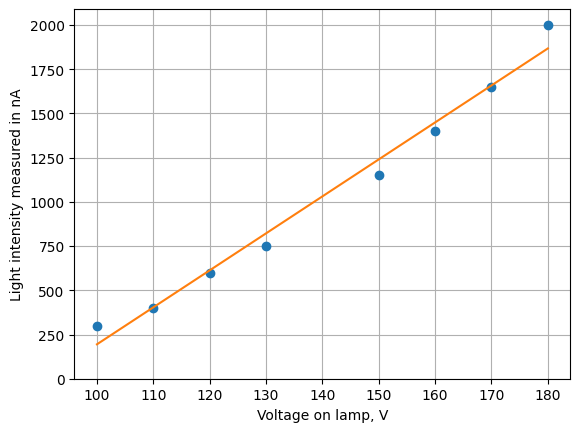

In [3]:
data = '''
# V I
180 20
170 16.5
160 14
150 11.5
130 7.5
120 6
110 4
100 3
'''
V, I = np.genfromtxt(data.splitlines()).T
I *= 1e-7 # A # I is on --30 scale on range 10^-7

fit_light = linregress(V, I)
plt.plot(V, I*1e9, 'o')
plt.plot(V, (fit_light.intercept + fit_light.slope * V)*1e9)
plt.xlabel('Voltage on lamp, V')
plt.ylabel('Light intensity measured in nA')
#plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid()


## Saturation current as a function of light intensity

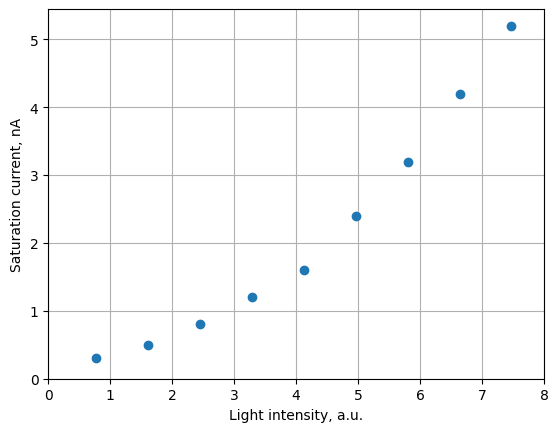

In [4]:
# nu = 500 nm
# V = 10 V # on anode /cathode
data = '''
# variac V/V I/10^-10 A
180 52
170 42
160 32
150 24
140 16
130 12
120 8
110 5
100 3
'''
V, I = np.genfromtxt(data.splitlines()).T
I *= 1e-10

light_intensity = V * fit_light.slope + fit_light.intercept
plt.plot(light_intensity*4e6, I*1e9, 'o')
plt.xlabel('Light intensity, a.u.')
plt.ylabel('Saturation current, nA')
plt.xlim(left=0)
plt.xticks(range(9))
plt.ylim(bottom=0)
plt.grid()


# Picoammeter digital and analogue readings comparison

On the back side of the picoammeter there are sockets for digital measurements. Let's see how they are aligned with analogue readings, both on x100 range and x30 range. We change light intensity using variac and write down readings of the picoammeter.



Text(0, 0.5, 'Current readings, pA')

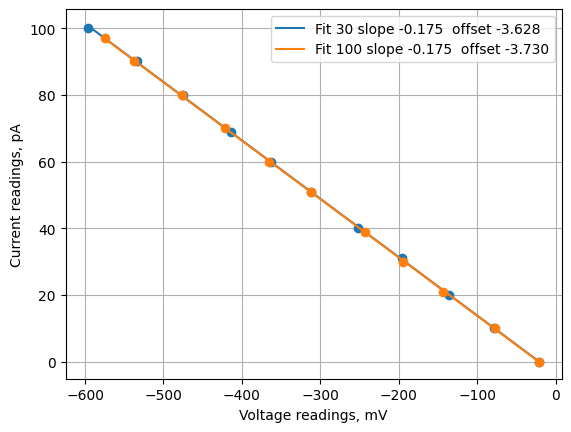

In [5]:
data30 = '''
# x30 scale, 10^-12
100 -596
90 -534
80 -475
69 -414
60 -363
51 -312
40 -252
31 -196
20 -136
10 -078
0 -021
#-1 -002 # full dark
'''
I30, V30 = np.genfromtxt(data30.splitlines()).T
plt.plot(V30, I30, 'o')
fit30 = linregress(V30, I30)
plt.plot(V30, fit30.intercept + fit30.slope * V30, color='C0',\
         label=f'Fit 30 slope {fit30.slope:.3f}  offset {fit30.intercept:.3f}')

data100 = '''
# after justifying zero
#-1 -004 # dark
0 -021
10 -077
21 -143
30 -194
39 -243
51 -312
60 -366
70 -422
80 -476
90 -537
97 -575
'''

I100, V100 = np.genfromtxt(data100.splitlines()).T
plt.plot(V100, I100, 'o')

fit100 = linregress(V100, I100)
plt.plot(V100, fit100.intercept + fit100.slope * V100, \
         color='C1', label=f'Fit 100 slope {fit100.slope:.3f}  offset {fit100.intercept:.3f}')
plt.grid()
plt.legend()
plt.xlabel('Voltage readings, mV')
plt.ylabel('Current readings, pA')

In [31]:
# function converting voltage readings to current readings
def V2I(V, order, divider=100):
  # order -12: pA, -11: x10  pA, -10: x100 pA
  # divider = 100 (scale x100) or 30 (scale x30)
  return ( fit100.slope * V) * divider / 100 * 10**order

# example
# picoammeter in scale 10^-12 divider 30
V = -4
print(f' Reading {V} mV, current {V2I(V, -12, 30)*1e12:.2f} pA')

 Reading -4 mV, current 0.21 pA


## Zero adjustment

Disconnect picoammeter. Slowly rotate `ZERO ADJ` screw until output miltimeter readings are less than 0.1 mV on lowest order 10^-12 and scale 30.. This correspondes to current less 0.01 pA.

## Dark current

In [7]:

# Current with lamp off and closed cover
data = '''
# V[V] Va[mV]
-0.0 -2.6 #+- 0.1 mV
'''

# example
# picoammeter in scale 10^-12 divider 30
V = -2.6
print(f' DMM readings {V} mV mean dark current {V2I(V, -12, 30)*1e12:.2f} pA')

 DMM readings -2.6 mV mean dark current 0.14 pA


#Volt-ampere curve

  Filter #2 Variac = 180V

Text(-0.8833333333333333, 0, 'V0 = -0.88 V')

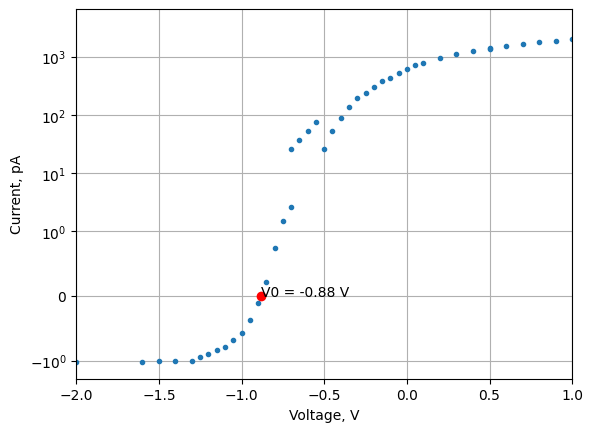

In [8]:
I = np.array([])
V = np.array([])

order, divider = -10, 100
data = '''
-193 19
-187 10
-177 5
-172 4
-163 3
-148 2
-113 1
-108 0.9
-102 .8
-095 .7
-088 .6
-079 .5
'''
Va, V_ = np.genfromtxt(data.splitlines()).T
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)

order, divider = -10, 30
data = '''
-267 .5
-242 .4
-210 .3
-183 .2
-151 .1
-137 .05
-119 .0
-101 -.05
-083 -.10
-074 -0.15
-058 -0.20
-046 -0.25
-037 -0.30
-026 -0.35
-017 -0.40
-010 -0.45
-005 -0.50
'''
Va, V_ = np.genfromtxt(data.splitlines()).T
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


order, divider = -11, 30
data = '''
-144 -0.55
-099 -0.60
-070 -0.65
-050 -0.70
'''
Va, V_ = np.genfromtxt(data.splitlines()).T
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)

order, divider = -12, 30
data = '''
-050 -0.70
-029 -0.75
-014 -0.80
-004 -0.85
002 -0.90
007 -0.95
011 -1.00
013 -1.05
015 -1.10
016 -1.15
017 -1.20
018 -1.25
019 -1.30
019 -1.40
019 -1.50
020 -1.60
020 -2.00
'''
Va, V_ = np.genfromtxt(data.splitlines()).T
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'V0 = {V0:.2f} V', (V0, 0))

Text(-0.6194328358208955, 0, '#1 V0 = -0.62 V')

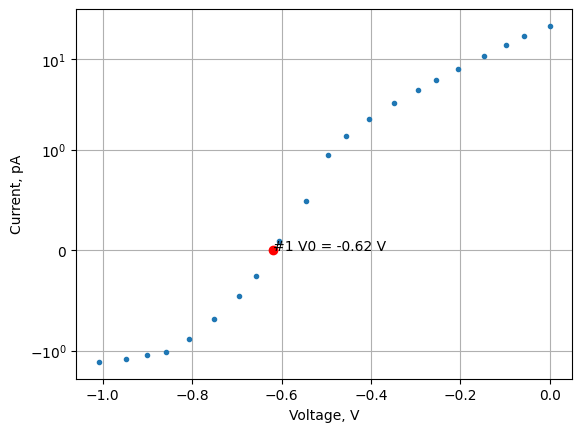

In [9]:
## Filter N1 585 nm, VAC = 180
I = np.array([])
V = np.array([])

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
-0 -445
-57 -340
-97 -275
-147 -208
-205 -150
-255 -112
-295 -088
-348 -063
-404 -042
-456 -027
-496 -18
-546 -9.3
-606 -1.8
-656 4.9
-696 8.6
-750 13
-807 16.8
-859 19.7
-900 21.5
-949 23.6
-1009 25.4
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'#1 V0 = {V0:.2f} V', (V0, 0))

Text(-0.8582, 0, '   #2 V0 = -0.86 V')

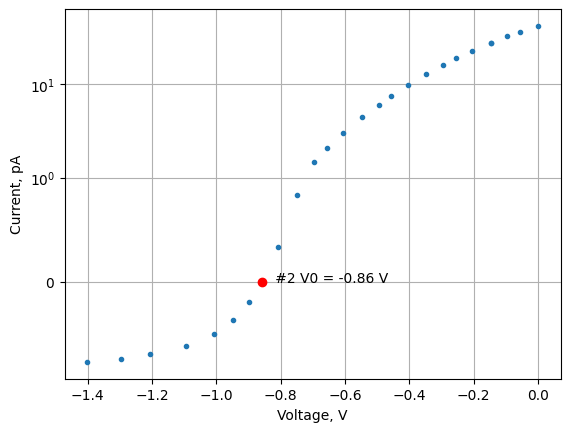

In [10]:
## Filter N2 455 nm, VAC = 180
I = np.array([])
V = np.array([])

order, divider = -12, 100
data = '''
# V[mV] Va[mv]
-0 -240
-57 -206
-97 -186
-147 -157
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
-147 -530
-205 -434
-255 -360
-295 -306
-348 -242
-404 -186
-457 -143
-496 -115
-546 -86
-606 -58
-656 -40
-696 -28
-750 -15.9
-807 -6.4
-859 0.1
-900 3.8
-949 7.0
-1009 9.5
-1095 11.8
-1205 13.3
-1298 14.1
-1402 14.7
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'   #2 V0 = {V0:.2f} V', (V0, 0))

IndexError: list index out of range

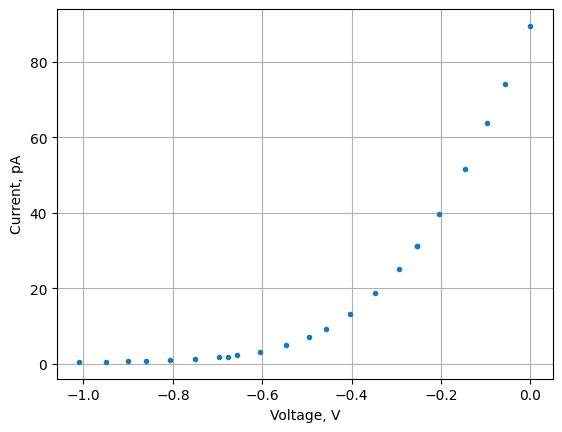

In [48]:
## Filter N3 500 nm, VAC = 180
I = np.array([])
V = np.array([])

order, divider = -12, 100
data = '''
# V[mV] Va[mv]
-0 -500
-57 -412
-97 -353
-147 -284
-205 -215
-254 -166
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
-254 -555
-295 -441
-348 -316
-404 -212
-457 -139
-496 -95
-546 -55
-606 -21
-656 -3.0
-676 2.4
-696 7.2
-750 16.4
-807 22.1
-859 25.5
-900 27.3
-949 28.7
-1009 29.7
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)

I += 2e-12 # pA

plt.plot(V, I*1e12, '.')
#plt.yscale('symlog', linthresh=1)
#plt.yscale('log')
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'   #3 V0 = {V0:.2f} V', (V0, 0))

Text(-0.5521224489795918, 0, '   #4 V0 = -0.55 V')

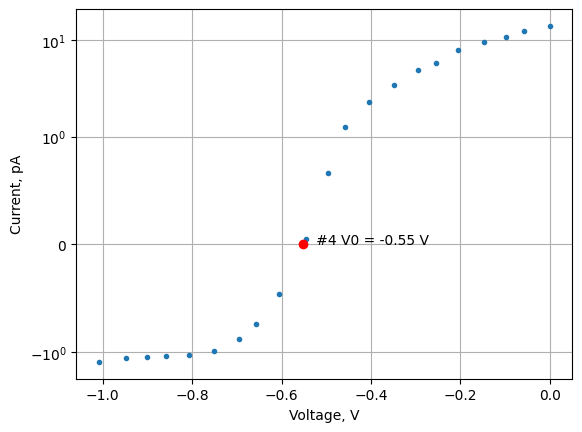

In [12]:
## Filter N4 555 nm, VAC = 180
I = np.array([])
V = np.array([])

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
-0 -265
-57 -235
-97 -205
-147 -180
-205 -148
-254 -110
-295 -92
-348 -65
-404 -43
-457 -24
-496 -12.7
-546 -1.0
-606 8.8
-656 14.1
-696 16.7
-750 18.8
-807 20.3
-859 21.0
-900 21.5
-949 22
-1009 24
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'   #4 V0 = {V0:.2f} V', (V0, 0))

Text(-0.32872727272727276, 0, '   #5 V0 = -0.33 V')

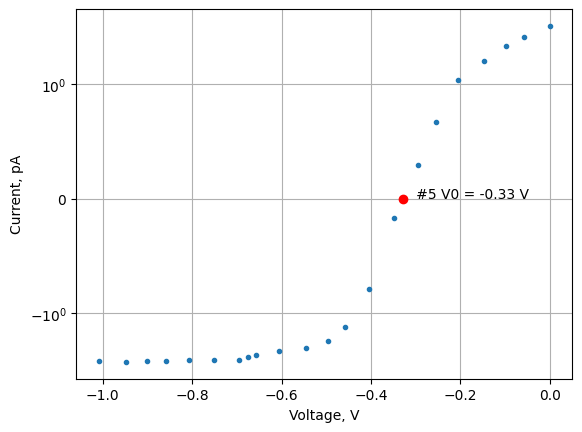

In [13]:
## Filter N5 620 nm, VAC = 180
I = np.array([])
V = np.array([])

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
-0 -70
-57 -55
-97 -45
-147 -32
-205 -21
-254 -12.8
-295 -5.6
-348 3.2
-404 15
-457 26
-496 36
-546 42
-606 45
-656 49
-676 51
-696 54
-750 54
-807 55
-859 56
-900 56
-949 57
-1009 56
'''
V_, Va = np.genfromtxt(data.splitlines()).T
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'   #5 V0 = {V0:.2f} V', (V0, 0))

Text(-1.5475, 0, '   Green 525nm V0 = -1.55 V')

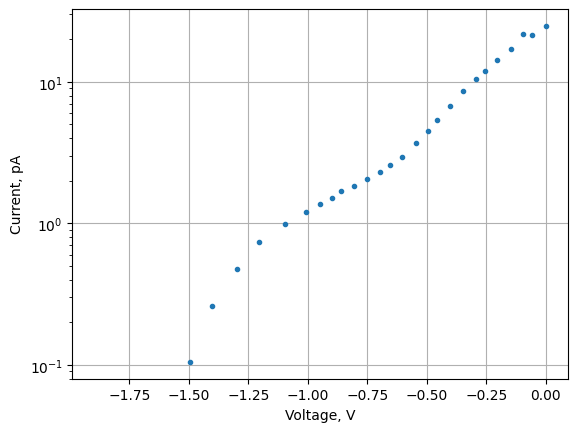

In [39]:
##  525 nm green diode, VAC = 180
I = np.array([])
V = np.array([])

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
-0 -477
-57 -412
-97 -418
-147 -328
-205 -274
-254 -233
-295 -203
-348 -167
-404 -132
-457 -106
-496 -90
-546 -74
-606 -60
-656 -53
-696 -48
-750 -43
-807 -39
-859 -36
-900 -33
-949 -30
-1009 -27
-1095 -23
-1205 -18
-1298 -13
-1403 -9
-1493 -6
-1602 -2
-1694 -0
-1804 4
-1894 7
'''
V_, Va = np.genfromtxt(data.splitlines()).T
Va -= -4 # dark current correction
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.yscale('log')
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

V0 = find_roots(V, I)[0]
plt.plot(V0, 0, 'o', color='red')
plt.annotate(f'   Green 525nm V0 = {V0:.2f} V', (V0, 0))

# Dark current

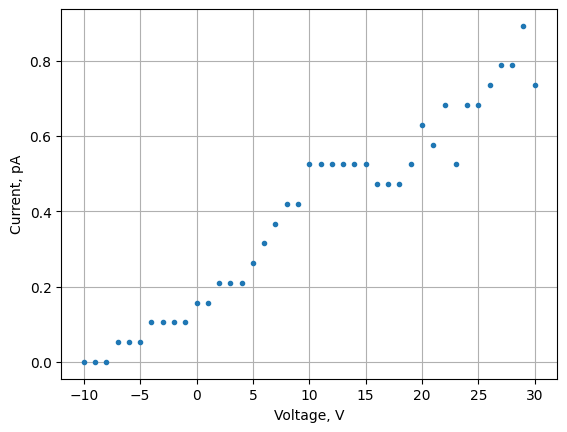

In [29]:
##  dark current
I = np.array([])
V = np.array([])

order, divider = -12, 30
data = '''
# V[mV] Va[mv]
30000 -014
29000 -017
28000 -015
27000 -015
26000 -014
25000 -013
24000 -013
23000 -010
22000 -013
21000 -11
20000 -012
19000 -010
18000 -009
17000 -009
16000 -009
15000 -010
14000 -010
13000 -010
12000 -010
11000 -010
10000 -010
9000 -008
8000 -008
7000 -007
6000 -006
5000 -005
4000 -004
3000 -004
2000 -004
1000 -003
0 -003
-1000 -002
-2000 -002
-3000 -002
-4000 -002
-5000 -001
-6000 -001
-7000 -001
-8000 0
-9000 0
-10000 0
'''
V_, Va = np.genfromtxt(data.splitlines()).T
#Va -= -43 # dark current correction
V_ *= 1e-3
I = np.append(I, V2I(Va, order, divider))
V = np.append(V, V_)


plt.plot(V, I*1e12, '.')
#plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)


# Plank's constant and Work potential determination

$$
\frac{h}{e} \nu = V_0(\nu) +  W
$$

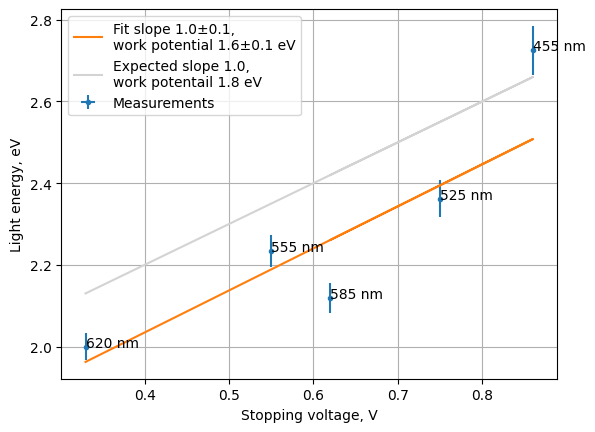

In [23]:
data = '''
585 0.62
455 0.86
#500 0.67
525 0.75
555 0.55
620 0.33
'''

def linear(voltage, slope, offset):
    return slope * voltage + offset


wl, V0 = np.genfromtxt(data.splitlines()).T

wl, V0 = np.genfromtxt(data.splitlines()).T

relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
energy_err = energy * relative_error
V_err = 2e-3 # V

# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset

popt, pcov = curve_fit(linear, V0, energy, sigma=energy_err, absolute_sigma=True)
slope = popt[0]
offset = popt[1]
errs = np.sqrt(np.diag(pcov))
slope_err = errs[0]
offset_err = errs[1]
offset_expected = 1.8 # for Cs-Sb Photocathode
plt.errorbar(V0, energy, yerr=energy_err, xerr=V_err, ls='', marker='.', label='Measurements')
plt.plot(V0, offset + slope * V0, label=f'Fit slope {slope:.1f}±{slope_err:.1f},\nwork potential {offset:.1f}±{offset_err:.1f} eV')
plt.plot(V0, offset_expected +  V0, color='lightgray', label=f'Expected slope 1.0,\nwork potentail {offset_expected:.1f} eV')

for i in range(len(V0)):
    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel('Stopping voltage, V')
plt.ylabel('Light energy, eV')
#plt.xlim(0.2, 1)
plt.show()

